# Прогноз аварийной остановки





ячейка в конце ноутбука,демо, запускаеться без Ран Алл, автономно


In [2]:
from dataclasses import asdict
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.calibration import SigmoidProbabilityCalibrator


ROOT = Path.cwd()
CANONICAL_ROOT = ROOT.parent
MODEL_PATH = CANONICAL_ROOT / "artifacts" / "final" / "model.joblib"
CALIBRATOR_PATH = CANONICAL_ROOT / "artifacts" / "final" / "calibrator.joblib"
POLICY_PATH = CANONICAL_ROOT / "artifacts" / "final" / "policy.json"
TARGET = "emergency_within_4h"
WARNING_THRESHOLD = 0.15
CRITICAL_THRESHOLD = 0.50
PERSISTENCE_POINTS = 2
CADENCE_MINUTES = 5


## Данные


Данные синтетические.

| набор | период | строк | допустимые / для модели | аварии | доля положительных |
|---|---|---:|---:|---:|---:|
| train | 2026-01-01 — 2026-04-30 | 34,560 | 25,812 / 22,884 | 60 | 12.585% |
| validation | 2026-05-01 — 2026-08-28 | 34,560 | 31,612 / 30,604 | 20 | 3.137% |
| final_test | 2026-08-29 — 2026-12-26 | 34,560 | 31,612 / 30,604 | 20 | 3.137% |

`valid_for_model` — допустимые строки; для модели остаются строки после
прогрева в 48 точек. `emergency_within_4h = 1` — доля положительных строк
среди строк для модели, а не доля аварий.

Валидация разделена по времени: калибровка (2026-05-01 — 2026-06-29) и
выбор порогов (2026-06-30 — 2026-08-28) содержат по 15,302 строк для модели,
10 аварий и 480 положительных строк.

Каждая половина валидации содержит 15 302 строки, на которых рассчитывается прогноз. Из них 480 строк относятся к четырёхчасовым интервалам перед 10 аварийными остановками и имеют emergency_within_4h = 1; остальные 14 822 строки имеют класс 0.


In [3]:
def load_development_split(split):
    split_root = CANONICAL_ROOT / "data" / split
    observed = pd.read_parquet(split_root / "observed.parquet")
    labels = pd.read_parquet(split_root / "labels.parquet")
    events = pd.read_parquet(split_root / "events.parquet")
    return observed, labels, events



model_config = json.loads(
    (CANONICAL_ROOT / "configs" / "model.json").read_text(encoding="utf-8")
)
train_observed, train_labels, train_events = load_development_split("train")
validation_observed, validation_labels, validation_events = load_development_split(
    "validation"
)
print(
    f"train: {len(train_observed)} строк; "
    f"validation: {len(validation_observed)} строк"
)


train: 34560 строк; validation: 34560 строк


## Признаки

Ниже находится  построение 133 признаков: 12 текущих значений телеметрии и 121 причинный временной признак. История сбрасывается на границе valid_for_model, а окно в 4 часа задаёт прогрев в 48 точек.

Синтетический процесс: нормальная работа → деградация → изменение телеметрии
→ срабатывание защиты → STOP. Перед STOP целевая переменная
`emergency_within_4h` равна 1 в окне 4 часа.

`valid_for_model` не входит в признаки. STOP и восстановление разрывают
временной сегмент, а `horizon_complete` исключает конец набора, для которого
ещё нет полного четырёхчасового окна разметки.


In [ ]:
"""Построение признаков для набора emergency_forecast_v2.

Модуль принимает только observed и labels. Events, audit, скрытые состояния и
защитные пороги не участвуют в построении признаков.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd


MODE_COLUMN = "operating_mode"
TIMESTAMP_COLUMN = "timestamp"
DELTA_HOURS = (0.25, 0.5, 1.0, 2.0, 4.0)
ROLLING_HOURS = (1.0, 4.0)


@dataclass(frozen=True)
class FeatureResult:
    # матрица признаков и маски ее применимости

    features: pd.DataFrame
    current_valid: np.ndarray
    temporal_valid: np.ndarray
    segment_id: np.ndarray
    specification: dict[str, Any]


def _hours_token(hours: float) -> str:
    # возвращает стабильный токен длительности для имени признака

    if float(hours).is_integer():
        return f"{int(hours)}h"
    minutes = int(round(hours * 60.0))
    return f"{minutes}min"


def _segments(
    valid: np.ndarray,
    timestamps: pd.DatetimeIndex,
    cadence_minutes: int,
) -> list[tuple[int, int]]:
    # возвращает границы непрерывных допустимых сегментов

    expected = pd.Timedelta(minutes=cadence_minutes)
    result: list[tuple[int, int]] = []
    start: int | None = None
    for index, is_valid in enumerate(valid):
        previous_is_valid = index > 0 and bool(valid[index - 1])
        continuous = index > 0 and timestamps[index] - timestamps[index - 1] == expected
        if bool(is_valid) and (not previous_is_valid or not continuous):
            start = index
        if start is not None and (
            not bool(is_valid)
            or index == len(valid) - 1
            or not bool(valid[index + 1])
            or timestamps[index + 1] - timestamps[index] != expected
        ):
            end = index if bool(is_valid) else index - 1
            if end >= start:
                result.append((start, end))
            start = None
    return result


def _causal_slope(values: np.ndarray, window: int, cadence_minutes: int) -> np.ndarray:
    # считает наклон на [t-window+1, t] в единицах канала в час

    result = np.full(values.size, np.nan, dtype=np.float64)
    if values.size < window:
        return result
    # x возрастает от самой старой точки к текущей и не содержит будущих строк
    x = np.arange(window, dtype=np.float64) * float(cadence_minutes) / 60.0
    x_centered = x - x.mean()
    denominator = float(np.dot(x_centered, x_centered))
    windows = np.lib.stride_tricks.sliding_window_view(values, window)
    result[window - 1 :] = (windows * x_centered).sum(axis=1) / denominator
    return result


def _feature_names(
    continuous_columns: list[str],
) -> tuple[list[str], list[str]]:
    # строит детерминированные имена текущих и временных признаков

    current = [MODE_COLUMN, *continuous_columns]
    temporal = list(current)
    for column in continuous_columns:
        for hours in DELTA_HOURS:
            temporal.append(f"{column}__delta_{_hours_token(hours)}")
        for statistic in ("mean", "std"):
            for hours in ROLLING_HOURS:
                temporal.append(f"{column}__rolling_{statistic}_{_hours_token(hours)}")
        for hours in ROLLING_HOURS:
            temporal.append(f"{column}__slope_{_hours_token(hours)}")
    return current, temporal


def build_features(
    observed: pd.DataFrame,
    labels: pd.DataFrame,
    *,
    cadence_minutes: int = 5,
) -> FeatureResult:
    """Строит текущие и строго причинные временные признаки.

    Скользящие окна включают текущую строку и предыдущие строки того же
    допустимого сегмента. Интервалы в 4 часа требуют ровно 48 предыдущих
    шагов сетки, поэтому временный прогрев заканчивается на 48 м шаге сегмента.
    """

    timestamps = pd.DatetimeIndex(pd.to_datetime(observed["timestamp"], utc=True))
    continuous_columns = [
        column for column in observed.columns if column not in {TIMESTAMP_COLUMN, MODE_COLUMN}
    ]
    current_names, temporal_names = _feature_names(continuous_columns)
    values = observed[continuous_columns].to_numpy(dtype=np.float64)
    mode = observed[MODE_COLUMN].to_numpy(dtype=np.int64)
    valid = labels["valid_for_model"].to_numpy(dtype=bool)
    segments = _segments(valid, timestamps, cadence_minutes)

    features = pd.DataFrame(
        {
            MODE_COLUMN: mode,
            **{
                column: values[:, column_index]
                for column_index, column in enumerate(continuous_columns)
            },
        },
        index=observed.index,
    )

    temporal_arrays: dict[str, np.ndarray] = {
        name: np.full(len(observed), np.nan, dtype=np.float64)
        for name in temporal_names[len(current_names) :]
    }
    segment_id = np.full(len(observed), -1, dtype=np.int32)
    temporal_valid = np.zeros(len(observed), dtype=bool)
    max_lag = int(round(4.0 * 60.0 / cadence_minutes))

    for current_segment_id, (start, end) in enumerate(segments):
        segment_id[start : end + 1] = current_segment_id
        segment_length = end - start + 1
        segment_frame = observed.iloc[start : end + 1]
        for column in continuous_columns:
            segment_values = segment_frame[column].to_numpy(dtype=np.float64)
            for hours in DELTA_HOURS:
                lag = int(round(hours * 60.0 / cadence_minutes))
                name = f"{column}__delta_{_hours_token(hours)}"
                temporal_arrays[name][start : end + 1] = segment_values - np.roll(
                    segment_values, lag
                )
                temporal_arrays[name][start : start + min(lag, segment_length)] = np.nan

            series = pd.Series(segment_values, dtype="float64")
            for statistic in ("mean", "std"):
                for hours in ROLLING_HOURS:
                    window = int(round(hours * 60.0 / cadence_minutes))
                    rolling = series.rolling(window=window, min_periods=window)
                    if statistic == "mean":
                        result = rolling.mean().to_numpy(dtype=np.float64)
                    else:
                        result = rolling.std(ddof=0).to_numpy(dtype=np.float64)
                    name = f"{column}__rolling_{statistic}_{_hours_token(hours)}"
                    temporal_arrays[name][start : end + 1] = result

            for hours in ROLLING_HOURS:
                window = int(round(hours * 60.0 / cadence_minutes))
                name = f"{column}__slope_{_hours_token(hours)}"
                temporal_arrays[name][start : end + 1] = _causal_slope(
                    segment_values,
                    window,
                    cadence_minutes,
                )

        # Интервал 4 часа задает границу прогрева для всех временных каналов.
        if segment_length > max_lag:
            temporal_valid[start + max_lag : end + 1] = True

    temporal_frame = pd.DataFrame(temporal_arrays, index=observed.index)
    features = pd.concat([features, temporal_frame], axis=1)

    specification = {
        "cadence_minutes": int(cadence_minutes),
        "current_features": current_names,
        "temporal_features": temporal_names,
        "continuous_channels": continuous_columns,
        "delta_hours": list(DELTA_HOURS),
        "rolling_hours": list(ROLLING_HOURS),
        "rolling_includes_current": True,
        "centered_rolling": False,
        "max_lag_steps": max_lag,
        "segment_boundary_column": "valid_for_model",
        "timestamp_is_feature": False,
        "forbidden_sources": [
            "audit",
            "events",
            "true_*",
            "counterfactual_*",
            "future masks",
            "protective thresholds",
            "absolute timestamp",
        ],
    }
    return FeatureResult(
        features=features,
        current_valid=valid,
        temporal_valid=temporal_valid,
        segment_id=segment_id,
        specification=specification,
    )


In [5]:
cadence = int(model_config["cadence_minutes"])
train_result = build_features(
    train_observed,
    train_labels,
    cadence_minutes=cadence,
)
validation_result = build_features(
    validation_observed,
    validation_labels,
    cadence_minutes=cadence,
)
current_names = train_result.specification["current_features"]
temporal_names = train_result.specification["temporal_features"]
train_target = train_labels[TARGET].to_numpy(dtype=np.int8)
validation_target = validation_labels[TARGET].to_numpy(dtype=np.int8)
train_timestamps = pd.DatetimeIndex(
    pd.to_datetime(train_observed["timestamp"], utc=True)
)
validation_timestamps = pd.DatetimeIndex(
    pd.to_datetime(validation_observed["timestamp"], utc=True)
)
data_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_observed),
            "current_features": len(current_names),
            "temporal_features": len(temporal_names),
            "temporal_valid_rows": int(train_result.temporal_valid.sum()),
        },
        {
            "split": "validation",
            "rows": len(validation_observed),
            "current_features": len(current_names),
            "temporal_features": len(temporal_names),
            "temporal_valid_rows": int(validation_result.temporal_valid.sum()),
        },
    ]
)
display(data_summary)


,split,rows,current_features,temporal_features,temporal_valid_rows
0,train,34560,12,133,22884
1,validation,34560,12,133,30604


## Временная КВ и модели

В каждом фолде модель обучается только на прошлом временном блоке,
затем вызывает `predict_proba` на следующем валид блолке. Для всех трёх
вариантов считаются PR-AUC, ROC-AUC, Brier и log loss.

PR-AUC показывает precision/recall при редком положительном классе: выше
лучше. ROC-AUC оценивает качество ранжирования: выше лучше. Brier оценивает
качество вероятностей: ниже лучше. Log loss сильнее штрафует уверенные
ошибочные вероятности: ниже лучше.


In [ ]:
"""Модели и временная кросс-валидация только по обучающим данным."""

from __future__ import annotations

from typing import Any

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier


DEFAULT_XGB_PARAMS: dict[str, Any] = {
    "max_depth": 3,
    "learning_rate": 0.05,
    "n_estimators": 300,
    "min_child_weight": 1,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
}


def make_xgb(
    params: dict[str, Any] | None = None,
    *,
    seed: int = 20260914,
) -> XGBClassifier:
    # создает детерминированный числовой классификатор XGBoost

    selected = {**DEFAULT_XGB_PARAMS, **(params or {})}
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=1,
        random_state=int(seed),
        seed=int(seed),
        verbosity=0,
        **selected,
    )


def make_logistic(
    feature_names: list[str],
    *,
    class_weight: str | None = None,
) -> Pipeline:
    # создает логистическую модель с обработкой, обучаемой только на трен фолде

    numeric = [name for name in feature_names if name != "operating_mode"]
    transformer = ColumnTransformer(
        transformers=[
            (
                "mode_one_hot",
                OneHotEncoder(
                    categories=[[0, 1, 2]],
                    handle_unknown="ignore",
                    sparse_output=False,
                    dtype=np.float64,
                ),
                ["operating_mode"],
            ),
            ("numeric_scale", StandardScaler(), numeric),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline(
        steps=[
            ("preprocess", transformer),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    class_weight=class_weight,
                    max_iter=1000,
                    solver="lbfgs",
                    random_state=0,
                ),
            ),
        ]
    )


def positive_probability(model: Any, features: pd.DataFrame) -> np.ndarray:
    return np.clip(model.predict_proba(features)[:, 1], 0.0, 1.0)


def binary_metrics(y_true: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.int8)
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1.0 - 1e-7)
    average_precision = float(average_precision_score(y_true, probability))
    return {
        "pr_auc": average_precision,
        "average_precision": average_precision,
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "brier": float(brier_score_loss(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "rows": int(y_true.size),
        "positive_rows": int(y_true.sum()),
        "prevalence": float(y_true.mean()),
    }


In [ ]:
"""Временная КВ и отложенная операционная оценка без доступа к файнал тест."""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Callable

import numpy as np
import pandas as pd



@dataclass(frozen=True)
class TemporalFold:
    # один расширяющийся временной фолд

    fold: int
    train_end_position: int
    validation_start_position: int
    validation_end_position: int
    gap_rows: int
    train_end_timestamp: str
    validation_start_timestamp: str
    validation_end_timestamp: str


def build_temporal_folds(
    timestamps: pd.Series | pd.DatetimeIndex,
    *,
    cadence_minutes: int,
    initial_train_days: int = 48,
    validation_days: int = 16,
    step_days: int = 16,
    gap_hours: int = 4,
    n_folds: int = 4,
) -> list[TemporalFold]:
    # строит расширяющиеся фОЛЛДЫ с зазором перед блоком валидации

    index = pd.DatetimeIndex(pd.to_datetime(timestamps, utc=True))
    rows_per_day = int(round(24 * 60 / cadence_minutes))
    gap_rows = int(round(gap_hours * 60 / cadence_minutes))
    train_rows = int(initial_train_days * rows_per_day)
    validation_rows = int(validation_days * rows_per_day)
    step_rows = int(step_days * rows_per_day)

    folds: list[TemporalFold] = []
    for fold in range(n_folds):
        train_end = train_rows + fold * step_rows
        validation_start = train_end + gap_rows
        validation_end = validation_start + validation_rows
        folds.append(
            TemporalFold(
                fold=fold,
                train_end_position=train_end,
                validation_start_position=validation_start,
                validation_end_position=validation_end,
                gap_rows=gap_rows,
                train_end_timestamp=index[train_end - 1].isoformat(),
                validation_start_timestamp=index[validation_start].isoformat(),
                validation_end_timestamp=index[validation_end - 1].isoformat(),
            )
        )
    return folds


def temporal_cv(
    features: pd.DataFrame,
    target: np.ndarray,
    feature_valid: np.ndarray,
    timestamps: pd.Series | pd.DatetimeIndex,
    folds: list[TemporalFold],
    model_factory: Callable[[], Any],
    *,
    model_name: str,
) -> tuple[list[dict[str, Any]], pd.DataFrame]:
    # обучает и получает прогноз только на каждом расширяющемся train block

    target = np.asarray(target, dtype=np.int8)
    feature_valid = np.asarray(feature_valid, dtype=bool)
    positions = np.arange(len(features))
    timestamp_index = pd.DatetimeIndex(pd.to_datetime(timestamps, utc=True))
    metric_rows: list[dict[str, Any]] = []
    prediction_rows: list[dict[str, Any]] = []
    for fold in folds:
        train_mask = feature_valid & (positions < fold.train_end_position)
        validation_mask = feature_valid & (
            (positions >= fold.validation_start_position)
            & (positions < fold.validation_end_position)
        )
        model = model_factory()
        model.fit(features.loc[train_mask], target[train_mask])
        probability = positive_probability(model, features.loc[validation_mask])
        metrics = binary_metrics(target[validation_mask], probability)
        metric_rows.append(
            {
                "model": model_name,
                "fold": fold.fold,
                "train_rows": int(train_mask.sum()),
                "validation_rows": int(validation_mask.sum()),
                "train_positive_rows": int(target[train_mask].sum()),
                "validation_positive_rows": int(target[validation_mask].sum()),
                "gap_rows": fold.gap_rows,
                "train_end_timestamp": fold.train_end_timestamp,
                "validation_start_timestamp": fold.validation_start_timestamp,
                "validation_end_timestamp": fold.validation_end_timestamp,
                **metrics,
            }
        )
        for row_position, value in zip(np.flatnonzero(validation_mask), probability):
            prediction_rows.append(
                {
                    "model": model_name,
                    "fold": fold.fold,
                    "row_position": int(row_position),
                    "timestamp": timestamp_index[row_position],
                    "target": int(target[row_position]),
                    "probability": float(value),
                }
            )
    return metric_rows, pd.DataFrame(prediction_rows)


def persistence_alarm(
    timestamps: pd.DatetimeIndex,
    probability: np.ndarray,
    threshold: float,
    *,
    persistence_points: int = 2,
    cadence_minutes: int = 5,
) -> np.ndarray:
    # применяет одинаковое требование N последовательных точек к сигналу

    probability = np.asarray(probability, dtype=np.float64)
    above = np.isfinite(probability) & (probability >= float(threshold))
    alarm = np.zeros(len(probability), dtype=bool)
    expected = pd.Timedelta(minutes=cadence_minutes)
    for index in range(persistence_points - 1, len(probability)):
        start = index - persistence_points + 1
        if not above[start : index + 1].all():
            continue
        window = timestamps[start : index + 1]
        if len(window) > 1 and not np.all(np.diff(window.asi8) == expected.value):
            continue
        alarm[index] = True
    return alarm


def _alarm_episodes(
    timestamps: pd.DatetimeIndex,
    alarm: np.ndarray,
    *,
    cadence_minutes: int,
) -> list[dict[str, Any]]:
    # собирает непрерывные эпизоды активного сигнала

    expected = pd.Timedelta(minutes=cadence_minutes)
    episodes: list[dict[str, Any]] = []
    start: int | None = None
    for index, active in enumerate(alarm):
        previous_active = index > 0 and bool(alarm[index - 1])
        continuous = index > 0 and timestamps[index] - timestamps[index - 1] == expected
        if bool(active) and (start is None or not previous_active or not continuous):
            if start is not None:
                episodes.append(
                    {
                        "start": timestamps[start],
                        "end": timestamps[index - 1],
                        "start_index": start,
                        "end_index": index - 1,
                    }
                )
            start = index
        if start is not None and (
            not bool(active)
            or index == len(alarm) - 1
            or not bool(alarm[index + 1])
            or timestamps[index + 1] - timestamps[index] != expected
        ):
            if bool(active):
                episodes.append(
                    {
                        "start": timestamps[start],
                        "end": timestamps[index],
                        "start_index": start,
                        "end_index": index,
                    }
                )
            start = None
    return episodes


def operational_metrics(
    predictions: pd.DataFrame,
    events: pd.DataFrame,
    *,
    threshold: float,
    policy_start: pd.Timestamp,
    policy_end: pd.Timestamp,
    horizon_hours: float = 4.0,
    persistence_points: int = 2,
    cadence_minutes: int = 5,
) -> dict[str, Any]:
    """ Оценивает, насколько хорошо WARNING и CRITICAL срабатывают на реальных аварийных событиях.
        Данные о событиях нужны только для оценки результатов и не используются моделью при прогнозе.
    """

    frame = predictions.sort_values("timestamp").reset_index(drop=True)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True)
    timestamps = pd.DatetimeIndex(frame["timestamp"])
    probability = frame["calibrated_probability"].to_numpy(dtype=np.float64)
    alarm = persistence_alarm(
        timestamps,
        probability,
        threshold,
        persistence_points=persistence_points,
        cadence_minutes=cadence_minutes,
    )
    frame["alarm"] = alarm

    emergency = events[events["event_kind"] == "emergency"].copy()
    emergency["stop"] = pd.to_datetime(emergency["emergency_timestamp"], utc=True)
    emergency = emergency.loc[
        (emergency["stop"] >= policy_start) & (emergency["stop"] < policy_end)
    ].copy()
    near_miss = events[events["event_kind"] == "near_miss"].copy()
    near_miss["start"] = pd.to_datetime(near_miss["degradation_start"], utc=True)
    near_miss["end"] = pd.to_datetime(near_miss["event_end"], utc=True)
    near_miss = near_miss.loc[
        (near_miss["end"] >= policy_start) & (near_miss["start"] < policy_end)
    ].copy()
    horizon = pd.Timedelta(hours=horizon_hours)
    stop_index = pd.DatetimeIndex(emergency["stop"])
    positive_window = np.zeros(len(timestamps), dtype=bool)
    for stop in stop_index:
        positive_window |= (timestamps >= stop - horizon) & (timestamps < stop)
    episodes = _alarm_episodes(timestamps, alarm, cadence_minutes=cadence_minutes)
    true_episodes = 0
    for episode in episodes:
        episode_start = episode["start"]
        episode_end = episode["end"]
        episode["event_related"] = bool(
            any(
                episode_start <= stop - pd.Timedelta(microseconds=1)
                and episode_end >= stop - horizon
                for stop in stop_index
            )
        )
        true_episodes += int(episode["event_related"])
    false_episodes = len(episodes) - true_episodes

    detected_rows: list[dict[str, Any]] = []
    for _, event in emergency.iterrows():
        stop = event["stop"]
        mask = (timestamps >= stop - horizon) & (timestamps < stop) & alarm
        matching = np.flatnonzero(mask)
        first_alarm = timestamps[matching[0]] if matching.size else pd.NaT
        detected_rows.append(
            {
                "event_id": str(event["event_id"]),
                "scenario_type": str(event["scenario_type"]),
                "detected": bool(matching.size),
                "first_alarm_timestamp": first_alarm,
                "lead_time_minutes": (
                    float((stop - first_alarm).total_seconds() / 60.0)
                    if matching.size
                    else np.nan
                ),
                "lead_ge_40_minutes": bool(
                    matching.size and (stop - first_alarm).total_seconds() / 60.0 >= 40.0
                ),
            }
        )
    detected = pd.DataFrame(detected_rows)
    near_alarm_rows: list[dict[str, Any]] = []
    for _, event in near_miss.iterrows():
        start = max(event["start"], policy_start)
        end = min(event["end"], policy_end - pd.Timedelta(microseconds=1))
        mask = (timestamps >= start) & (timestamps <= end) & alarm
        near_alarm_rows.append(
            {
                "event_id": str(event["event_id"]),
                "subtype": str(event["subtype"]),
                "alarm": bool(mask.any()),
            }
        )
    near_alarm = pd.DataFrame(near_alarm_rows)
    
    policy_days = (policy_end - policy_start).total_seconds() / 86_400.0
    lead_values = detected.loc[detected["detected"], "lead_time_minutes"]
    event_count = len(detected)
    detected_count = int(detected["detected"].sum())
    alarm_count = len(episodes)
    return {
        "threshold": float(threshold),
        "persistence_points": int(persistence_points),
        "policy_start": policy_start.isoformat(),
        "policy_end": policy_end.isoformat(),
        "policy_days": float(policy_days),
        "rows": int(len(frame)),
        "positive_rows": int(frame["target"].sum()),
        "row_metrics": binary_metrics(
            frame["target"].to_numpy(dtype=np.int8),
            frame["calibrated_probability"].to_numpy(dtype=float),
        ),
        "event_count": int(event_count),
        "event_recall": float(detected_count / event_count),
        "detected_events": detected_count,
        "median_lead_time_minutes": float(lead_values.median()),
        "p10_lead_time_minutes": float(lead_values.quantile(0.10)),
        "p90_lead_time_minutes": float(lead_values.quantile(0.90)),
        "lead_ge_40_recall": float(detected["lead_ge_40_minutes"].mean()),
        "alarm_episodes": int(alarm_count),
        "true_alarm_episodes": int(true_episodes),
        "false_alarm_episodes": int(false_episodes),
        "false_alarm_episodes_per_30d": float(false_episodes / policy_days * 30.0),
        "alarm_precision": float(true_episodes / alarm_count),
        "near_miss_count": int(len(near_alarm)),
        "near_miss_alarm_rate": float(near_alarm["alarm"].mean()),
        "positive_window_rows": int(positive_window.sum()),
        "event_rows": detected.to_dict(orient="records"),
        "near_miss_rows": near_alarm.to_dict(orient="records"),
        "episodes": [
            {
                "start": episode["start"].isoformat(),
                "end": episode["end"].isoformat(),
                "event_related": bool(episode["event_related"]),
            }
            for episode in episodes
        ],
    }


In [8]:
def _cv_summary(rows: list[dict[str, Any]]) -> pd.DataFrame:
    frame = pd.DataFrame(rows)
    numeric = ["pr_auc", "roc_auc", "brier", "log_loss"]
    summary_rows: list[dict[str, Any]] = []
    for model, group in frame.groupby("model", sort=False):
        row: dict[str, Any] = {
            "model": model,
            "folds": int(group["fold"].nunique()),
            "rows_total": int(group["validation_rows"].sum()),
        }
        for metric in numeric:
            row[f"mean_{metric}"] = float(group[metric].mean())
            row[f"std_{metric}"] = float(group[metric].std(ddof=0))
        summary_rows.append(row)
    return pd.DataFrame(summary_rows)

def _search_parameters(config: dict[str, Any]) -> list[dict[str, Any]]:
    # генерирует  25 детерминированных кандидатов, включая baseline

    search = config["xgboost_search"]
    ranges = search["ranges"]
    rng = np.random.default_rng(int(search["seed"]))
    params: list[dict[str, Any]] = [dict(config["models"]["xgboost_temporal_baseline"])]
    for _ in range(int(search["trials"]) - 1):
        params.append(
            {
                "max_depth": int(rng.integers(ranges["max_depth"][0], ranges["max_depth"][1] + 1)),
                "learning_rate": float(round(rng.uniform(*ranges["learning_rate"]), 5)),
                "n_estimators": int(rng.integers(ranges["n_estimators"][0], ranges["n_estimators"][1] + 1)),
                "min_child_weight": int(
                    rng.integers(ranges["min_child_weight"][0], ranges["min_child_weight"][1] + 1)
                ),
                "subsample": float(round(rng.uniform(*ranges["subsample"]), 5)),
                "colsample_bytree": float(round(rng.uniform(*ranges["colsample_bytree"]), 5)),
                "reg_lambda": float(round(rng.uniform(*ranges["reg_lambda"]), 5)),
                "reg_alpha": float(round(rng.uniform(*ranges["reg_alpha"]), 5)),
            }
        )
    return params

def _select_search_result(frame: pd.DataFrame) -> pd.Series:
    ordered = frame.sort_values(
        ["mean_pr_auc", "mean_log_loss", "trial"],
        ascending=[False, True, True],
        kind="mergesort",
    )
    return ordered.iloc[0]


In [9]:
seed = int(model_config["random_seed"])
cv_config = model_config["temporal_cv"]
folds = build_temporal_folds(
    train_observed["timestamp"],
    cadence_minutes=cadence,
    initial_train_days=int(cv_config["initial_train_days"]),
    validation_days=int(cv_config["validation_days"]),
    step_days=int(cv_config["step_days"]),
    gap_hours=int(cv_config["gap_hours"]),
    n_folds=int(cv_config["folds"]),
)
common_valid = train_result.temporal_valid

current_rows, current_predictions = temporal_cv(
    train_result.features[current_names],
    train_target,
    common_valid,
    train_observed["timestamp"],
    folds,
    lambda: make_xgb(
        model_config["models"]["xgboost_current_state"],
        seed=seed,
    ),
    model_name="xgboost_current_state",
)
logistic_rows, logistic_predictions = temporal_cv(
    train_result.features[temporal_names],
    train_target,
    common_valid,
    train_observed["timestamp"],
    folds,
    lambda: make_logistic(
        temporal_names,
        class_weight=model_config["models"]["logistic_temporal"]["class_weight"],
    ),
    model_name="logistic_temporal",
)
temporal_rows, temporal_predictions = temporal_cv(
    train_result.features[temporal_names],
    train_target,
    common_valid,
    train_observed["timestamp"],
    folds,
    lambda: make_xgb(
        model_config["models"]["xgboost_temporal_baseline"],
        seed=seed,
    ),
    model_name="xgboost_temporal_baseline",
)

cv_rows = current_rows + logistic_rows + temporal_rows
cv_summary = _cv_summary(cv_rows)
cv_fold_table = pd.DataFrame([asdict(fold) for fold in folds])


display(
    cv_fold_table[
        [
            "fold",
            "train_end_timestamp",
            "validation_start_timestamp",
            "validation_end_timestamp",
            "gap_rows",
        ]
    ]
)
display(
    cv_summary[
        [
            "model",
            "folds",
            "mean_pr_auc",
            "mean_roc_auc",
            "mean_brier",
            "mean_log_loss",
        ]
    ]
)


,fold,train_end_timestamp,validation_start_timestamp,validation_end_timestamp,gap_rows
0,0,2026-02-17T23:55:00+00:00,2026-02-18T04:00:00+00:00,2026-03-06T03:55:00+00:00,48
1,1,2026-03-05T23:55:00+00:00,2026-03-06T04:00:00+00:00,2026-03-22T03:55:00+00:00,48
2,2,2026-03-21T23:55:00+00:00,2026-03-22T04:00:00+00:00,2026-04-07T03:55:00+00:00,48
3,3,2026-04-06T23:55:00+00:00,2026-04-07T04:00:00+00:00,2026-04-23T03:55:00+00:00,48


,model,folds,mean_pr_auc,mean_roc_auc,mean_brier,mean_log_loss
0,xgboost_current_state,4,0.825825,0.960110,0.048639,0.175926
1,logistic_temporal,4,0.804834,0.945299,0.053427,0.263333
2,xgboost_temporal_baseline,4,0.839910,0.962362,0.047054,0.165859


По результатам временной кросс-валидации лучше всего показал себя XGBoost с временными признаками: у него самый высокий PR-AUC и ROC-AUC и одновременно самые низкие Brier score и log loss. При этом прирост относительно XGBoost только на текущих значениях небольшой, но стабильный по итоговым средним метрикам. Поэтому дальше в качестве основной модели был выбран XGBoost с временными признаками, а следующим этапом стал подбор его гиперпараметров.

## Выбор XGBoost и обучение

Поиск выполняет 25 детерминированных кандидатов на тех же фоллдах. Победитель выбирается по среднему PR-AUC, затем по log loss и номеру испытания, после чего обучается на всех допустимых строках train.

In [10]:
search_rows = []
search_params = _search_parameters(model_config)
for trial, params in enumerate(search_params):
    rows, _ = temporal_cv(
        train_result.features[temporal_names],
        train_target,
        common_valid,
        train_observed["timestamp"],
        folds,
        lambda params=params: make_xgb(params, seed=seed),
        model_name=f"xgboost_temporal_search_{trial:02d}",
    )
    search_rows.append(
        {
            "trial": trial,
            **params,
            **_cv_summary(rows).iloc[0].to_dict(),
        }
    )

search_frame = pd.DataFrame(search_rows)
selected_row = _select_search_result(search_frame)
selected_params = {key: selected_row[key] for key in DEFAULT_XGB_PARAMS}
for key in ("max_depth", "n_estimators", "min_child_weight"):
    selected_params[key] = int(selected_params[key])
for key in (
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
    "reg_alpha",
):
    selected_params[key] = float(selected_params[key])

selected_search_result = pd.DataFrame(
    [
        {
            "trial": int(selected_row["trial"]),
            "trials_evaluated": len(search_params),
            **selected_params,
        }
    ]
)


display(selected_search_result)


,trial,trials_evaluated,max_depth,learning_rate,n_estimators,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha
0,23,25,3,0.03274,280,7,0.80338,0.86325,1.22938,1.68898


Было проверено 25 конфигураций XGBoost на временной кросс-валидации. Лучший результат показал trial 23. Он использует неглубокие деревья (max_depth=3), небольшой learning_rate и умеренную регуляризацию, поэтому дальше именно эта конфигурация использовалась для обучения финальной модели.

In [11]:
train_model = make_xgb(selected_params, seed=seed)
train_model.fit(
    train_result.features.loc[train_result.temporal_valid, temporal_names],
    train_target[train_result.temporal_valid],
)
joblib.dump(train_model, MODEL_PATH)
print(f"Model saved: {MODEL_PATH.relative_to(CANONICAL_ROOT)}")


Model saved: artifacts/final/model.joblib


## Прогнозы на validation и калибровка

Выбранная модель получает исходные вероятности для всех допустимых строк валидации. Первые 60 дней используются только для Platt calibration; оставшиеся 60 дней остаются для policy.

In [12]:
validation_start = validation_timestamps[0]
calibration_end = validation_start + pd.Timedelta(
    days=int(model_config["validation_split"]["calibration_days"])
)
policy_end = validation_timestamps[-1] + pd.Timedelta(minutes=cadence)
calibration_mask = (
    validation_result.temporal_valid
    & (validation_timestamps < calibration_end)
)
policy_mask = (
    validation_result.temporal_valid
    & (validation_timestamps >= calibration_end)
)
raw_validation = np.full(len(validation_target), np.nan, dtype=np.float64)
raw_validation[validation_result.temporal_valid] = positive_probability(
    train_model,
    validation_result.features.loc[
        validation_result.temporal_valid,
        temporal_names,
    ],
)
raw_calibration = raw_validation[calibration_mask]
raw_policy = raw_validation[policy_mask]

calibrator = SigmoidProbabilityCalibrator(
    random_state=int(model_config["calibration"]["seed"])
)
calibrator.fit(raw_calibration, validation_target[calibration_mask])
joblib.dump(calibrator, CALIBRATOR_PATH)
print(f"Calibrator saved: {CALIBRATOR_PATH.relative_to(CANONICAL_ROOT)}")
calibrated_calibration = calibrator.transform(raw_calibration)
calibrated_policy = calibrator.transform(raw_policy)

calibration_results = pd.DataFrame(
    [
        {
            "stage": "raw",
            **binary_metrics(
                validation_target[calibration_mask],
                raw_calibration,
            ),
        },
        {
            "stage": "calibrated",
            **binary_metrics(
                validation_target[calibration_mask],
                calibrated_calibration,
            ),
        },
    ]
)
validation_metrics = pd.DataFrame(
    [
        {
            "split": "validation_policy",
            **binary_metrics(
                validation_target[policy_mask],
                calibrated_policy,
            ),
        }
    ]
)


display(
    calibration_results[
        ["stage", "pr_auc", "roc_auc", "brier", "log_loss", "rows"]
    ]
)
display(
    validation_metrics[
        ["split", "pr_auc", "roc_auc", "brier", "log_loss", "rows"]
    ]
)


Calibrator saved: artifacts/final/calibrator.joblib


,stage,pr_auc,roc_auc,brier,log_loss,rows
0,raw,0.553618,0.977184,0.025292,0.087927,15302
1,calibrated,0.553618,0.977184,0.020347,0.069030,15302


,split,pr_auc,roc_auc,brier,log_loss,rows
0,validation_policy,0.614898,0.972441,0.018432,0.064769,15302


После калибровки качество ранжирования не изменилось, зато сами вероятности стали точнее: снизились Brier score и log loss. Поэтому дальше для WARNING и CRITICAL использовались уже откалиброванные вероятности.
На второй половине валидаиооных данных проверялась уже готовая откалиброванная модель. Полученные метрики использовались как контроль качества перед оценкой рабочих порогов WARNING и CRITICAL.

## Policy

подбор порогов для политики сигнализации


In [13]:
threshold_sweep = pd.read_csv(
    CANONICAL_ROOT / "outputs" / "metrics" / "validation_policy_threshold_tradeoff.csv"
)
threshold_view = threshold_sweep.loc[
    threshold_sweep["threshold"].round(2).isin([0.10, 0.15, 0.20, 0.45, 0.50, 0.55, 0.75]),
    [
        "threshold",
        "event_recall",
        "detected_events",
        "median_lead_time_minutes",
        "false_alarm_episodes_per_30d",
        "alarm_precision",
    ],
]
display(threshold_view)


,threshold,event_recall,detected_events,median_lead_time_minutes,false_alarm_episodes_per_30d,alarm_precision
0,0.10,1.0,10,205.0,8.0,0.466667
1,0.15,1.0,10,187.5,7.5,0.500000
2,0.20,1.0,10,167.5,9.5,0.406250
7,0.45,0.7,7,145.0,4.5,0.590909
8,0.50,0.7,7,140.0,1.5,0.850000
9,0.55,0.7,7,105.0,2.0,0.714286
13,0.75,0.4,4,82.5,0.0,1.000000


Для WARNING лучше лишний раз предупредить, чем пропустить аварию. Поэтому лучше 0.15 : он ловит все 10 из 10 аварий, а ложных тревог при этом меньше, чем у 0.10 и 0.20.

Для CRITICAL уже важнее, чтобы сигнал был действительно серьёзным. Поэтому взяли 0.50: он ловит те же 7 из 10 аварий, что 0.45 и 0.55, но даёт меньше ложных тревог и выше точность. 0.75 ещё точнее, но уже пропускает слишком много аварий — ловит только 4 из 10.

In [14]:
policy_timestamps = validation_timestamps[policy_mask]
policy_predictions = pd.DataFrame(
    {
        "timestamp": policy_timestamps,
        "raw_probability": raw_policy,
        "calibrated_probability": calibrated_policy,
        "target": validation_target[policy_mask],
        "valid_segment_id": validation_result.segment_id[policy_mask],
    }
)
warning_policy = operational_metrics(
    policy_predictions,
    validation_events,
    threshold=WARNING_THRESHOLD,
    policy_start=calibration_end,
    policy_end=policy_end,
    horizon_hours=float(model_config["horizon_hours"]),
    persistence_points=PERSISTENCE_POINTS,
    cadence_minutes=cadence,
)
critical_policy = operational_metrics(
    policy_predictions,
    validation_events,
    threshold=CRITICAL_THRESHOLD,
    policy_start=calibration_end,
    policy_end=policy_end,
    horizon_hours=float(model_config["horizon_hours"]),
    persistence_points=PERSISTENCE_POINTS,
    cadence_minutes=cadence,
)
policy_results = pd.DataFrame(
    [
        {"level": "WARNING", **warning_policy},
        {"level": "CRITICAL", **critical_policy},
    ]
)


display(
    policy_results[
        [
            "level",
            "threshold",
            "event_recall",
            "median_lead_time_minutes",
            "false_alarm_episodes_per_30d",
            "alarm_precision",
        ]
    ]
)


,level,threshold,event_recall,median_lead_time_minutes,false_alarm_episodes_per_30d,alarm_precision
0,WARNING,0.15,1.0,187.5,7.5,0.50
1,CRITICAL,0.50,0.7,140.0,1.5,0.85


## Итоговые результаты

трейн используется для обучения и крос валидации. валидейшен используется
для калибровки.


Для финальной проверки загружаются сохранённые модель и калибратор.
файнал тест не участвует в обучении, калибровке и выборе порогов.


In [15]:
def evaluate_final_test():

    final_observed, final_labels, final_events = load_development_split("final_test")
    final_result = build_features(
        final_observed,
        final_labels,
        cadence_minutes=CADENCE_MINUTES,
    )
    final_model = joblib.load(MODEL_PATH)
    final_calibrator = joblib.load(CALIBRATOR_PATH)
    feature_names = final_result.specification["temporal_features"]
    valid = final_result.temporal_valid
    target = final_labels[TARGET].to_numpy(dtype=np.int8)
    raw = np.full(len(target), np.nan, dtype=float)
    raw[valid] = positive_probability(
        final_model,
        final_result.features.loc[valid, feature_names],
    )
    calibrated = np.full(len(target), np.nan, dtype=float)
    calibrated[valid] = final_calibrator.transform(raw[valid])
    timestamps = pd.DatetimeIndex(pd.to_datetime(final_observed["timestamp"], utc=True))
    predictions = pd.DataFrame(
        {
            "timestamp": timestamps[valid],
            "calibrated_probability": calibrated[valid],
            "target": target[valid],
            "valid_segment_id": final_result.segment_id[valid],
        }
    )
    final_metrics = binary_metrics(
        predictions["target"].to_numpy(dtype=np.int8),
        predictions["calibrated_probability"].to_numpy(dtype=float),
    )
    final_start = timestamps[0]
    final_end = timestamps[-1] + pd.Timedelta(minutes=CADENCE_MINUTES)
    policy = json.loads(POLICY_PATH.read_text(encoding="utf-8"))
    warning = operational_metrics(
        predictions,
        final_events,
        threshold=float(policy["warning"]["threshold"]),
        policy_start=final_start,
        policy_end=final_end,
        horizon_hours=4.0,
        persistence_points=int(policy["warning"]["persistence_points"]),
        cadence_minutes=CADENCE_MINUTES,
    )
    critical = operational_metrics(
        predictions,
        final_events,
        threshold=float(policy["critical"]["threshold"]),
        policy_start=final_start,
        policy_end=final_end,
        horizon_hours=4.0,
        persistence_points=int(policy["critical"]["persistence_points"]),
        cadence_minutes=CADENCE_MINUTES,
    )
    return (
        pd.DataFrame([{"split": "final_test", **final_metrics}]),
        pd.DataFrame(
            [
                {"level": "WARNING", **warning},
                {"level": "CRITICAL", **critical},
            ]
        ),
    )


final_test_metrics, final_test_policy = evaluate_final_test()
display(
    final_test_metrics[
        ["split", "pr_auc", "roc_auc", "brier", "log_loss", "rows"]
    ]
)
display(
    final_test_policy[
        [
            "level",
            "threshold",
            "event_recall",
            "median_lead_time_minutes",
            "false_alarm_episodes_per_30d",
            "alarm_precision",
        ]
    ]
)


,split,pr_auc,roc_auc,brier,log_loss,rows
0,final_test,0.536488,0.964508,0.020475,0.071934,30604


,level,threshold,event_recall,median_lead_time_minutes,false_alarm_episodes_per_30d,alarm_precision
0,WARNING,0.15,0.95,205.0,9.25,0.350877
1,CRITICAL,0.50,0.80,147.5,4.50,0.550000


Первая таблица показывает общие метрики модели на независимом final_test без привязки к конкретным порогам WARNING/CRITICAL. Здесь оценивается, насколько хорошо модель в целом ранжирует опасные состояния выше нормальных и насколько качественно выдаёт вероятности.


Первая таблица оценивает качество вероятностных прогнозов модели относительно истинной разметки: и точность самих вероятностей, и качество ранжирования аварийных и нормальных состояний.

 Вторая таблица уже показывает практическую работу зафиксированных порогов WARNING = 0.15 и CRITICAL = 0.50: сколько аварийных событий они обнаруживают, насколько заранее срабатывают, сколько дают ложных тревог и какая доля срабатываний оказывается полезной. То есть первая таблица оценивает качество самой вероятностной модели, а вторая качество работы уже готовой системы оповещения.

## демо

Последняя ячейка автономна
Она использует только публичный `example_trace.csv` и сохранённые model
artifacts, сохраняя рабочую инференс логику и формат сообщений.


Демонстрация: 3 секунды = 5 минут модельного времени
На экране: P01, P08, P05
Для прогноза используются все 133 признака.

09:35 | P01=71.341 | P08=0.793 | P05=4.424 | P(авария ≤ 4ч)=0.0174 | NORMAL
09:40 | P01=71.414 | P08=0.774 | P05=4.457 | P(авария ≤ 4ч)=0.0140 | NORMAL
09:45 | P01=71.434 | P08=0.775 | P05=4.426 | P(авария ≤ 4ч)=0.0195 | NORMAL
09:50 | P01=71.423 | P08=0.811 | P05=4.458 | P(авария ≤ 4ч)=0.1388 | NORMAL
09:55 | P01=71.442 | P08=0.782 | P05=4.424 | P(авария ≤ 4ч)=0.0575 | NORMAL
10:00 | P01=71.530 | P08=0.755 | P05=4.434 | P(авария ≤ 4ч)=0.2415 | WARNING candidate 1/2
10:05 | P01=71.638 | P08=0.793 | P05=4.444 | P(авария ≤ 4ч)=0.2105 | WARNING
>>> WARNING подтверждён (2/2) — сигнал отправлен на сигнализацию
10:10 | P01=71.544 | P08=0.798 | P05=4.528 | P(авария ≤ 4ч)=0.3390 | WARNING
10:15 | P01=71.647 | P08=0.796 | P05=4.555 | P(авария ≤ 4ч)=0.2276 | WARNING
10:20 | P01=71.578 | P08=0.779 | P05=4.545 | P(авария ≤ 4ч)=0.3309 | WARNING
10:25 | P01=71.664 | P08=0.787 | 

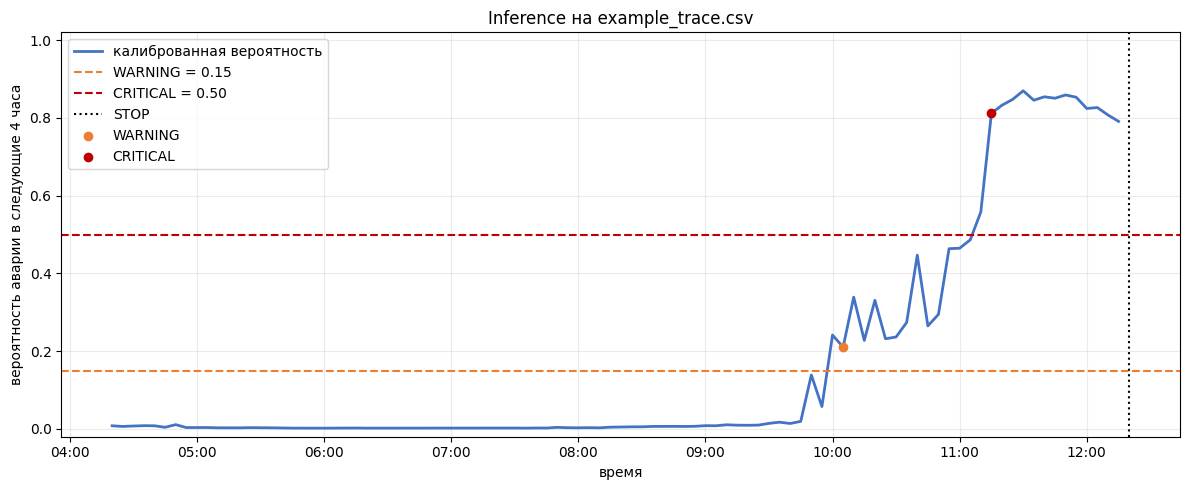

In [16]:
"""Построение признаков 
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd


MODE_COLUMN = "operating_mode"
TIMESTAMP_COLUMN = "timestamp"
DELTA_HOURS = (0.25, 0.5, 1.0, 2.0, 4.0)
ROLLING_HOURS = (1.0, 4.0)


@dataclass(frozen=True)
class FeatureResult:
    # матрица признаков и маски ее применимости

    features: pd.DataFrame
    current_valid: np.ndarray
    temporal_valid: np.ndarray
    segment_id: np.ndarray
    specification: dict[str, Any]


def _hours_token(hours: float) -> str:
    # возвращает стабильный токен длительности для имени признака

    if float(hours).is_integer():
        return f"{int(hours)}h"
    minutes = int(round(hours * 60.0))
    return f"{minutes}min"


def _segments(
    valid: np.ndarray,
    timestamps: pd.DatetimeIndex,
    cadence_minutes: int,
) -> list[tuple[int, int]]:
    # возвращает границы непрерывных допустимых сегментов

    expected = pd.Timedelta(minutes=cadence_minutes)
    result: list[tuple[int, int]] = []
    start: int | None = None
    for index, is_valid in enumerate(valid):
        previous_is_valid = index > 0 and bool(valid[index - 1])
        continuous = index > 0 and timestamps[index] - timestamps[index - 1] == expected
        if bool(is_valid) and (not previous_is_valid or not continuous):
            start = index
        if start is not None and (
            not bool(is_valid)
            or index == len(valid) - 1
            or not bool(valid[index + 1])
            or timestamps[index + 1] - timestamps[index] != expected
        ):
            end = index if bool(is_valid) else index - 1
            if end >= start:
                result.append((start, end))
            start = None
    return result


def _causal_slope(values: np.ndarray, window: int, cadence_minutes: int) -> np.ndarray:
    # считает наклон на [t-window+1, t] в единицах канала в час

    result = np.full(values.size, np.nan, dtype=np.float64)
    # x возрастает от самой старой точки к текущей и не содержит будущих строк
    x = np.arange(window, dtype=np.float64) * float(cadence_minutes) / 60.0
    x_centered = x - x.mean()
    denominator = float(np.dot(x_centered, x_centered))
    windows = np.lib.stride_tricks.sliding_window_view(values, window)
    result[window - 1 :] = (windows * x_centered).sum(axis=1) / denominator
    return result


def _feature_names(
    continuous_columns: list[str],
) -> tuple[list[str], list[str]]:
    # строит детерминированные имена текущих и временных признаков

    current = [MODE_COLUMN, *continuous_columns]
    temporal = list(current)
    for column in continuous_columns:
        for hours in DELTA_HOURS:
            temporal.append(f"{column}__delta_{_hours_token(hours)}")
        for statistic in ("mean", "std"):
            for hours in ROLLING_HOURS:
                temporal.append(f"{column}__rolling_{statistic}_{_hours_token(hours)}")
        for hours in ROLLING_HOURS:
            temporal.append(f"{column}__slope_{_hours_token(hours)}")
    return current, temporal


def build_features(
    observed: pd.DataFrame,
    labels: pd.DataFrame,
    *,
    cadence_minutes: int = 5,
) -> FeatureResult:
    """Строит текущие и строго причинные временные признаки.

    Скользящие окна включают текущую строку и предыдущие строки того же
    допустимого сегмента. Интервалы в 4 часа требуют ровно 48 предыдущих
    шагов сетки, поэтому временный прогрев заканчивается на 48 шаге сегмента.
    """

    timestamps = pd.DatetimeIndex(pd.to_datetime(observed[TIMESTAMP_COLUMN], utc=True))
    label_timestamps = pd.DatetimeIndex(pd.to_datetime(labels[TIMESTAMP_COLUMN], utc=True))
    if not timestamps.equals(label_timestamps):
        raise ValueError("observed и labels не выровнены по timestamp")
    continuous_columns = [
        column for column in observed.columns if column not in {TIMESTAMP_COLUMN, MODE_COLUMN}
    ]
    current_names, temporal_names = _feature_names(continuous_columns)
    values = observed[continuous_columns].to_numpy(dtype=np.float64)
    mode = observed[MODE_COLUMN].to_numpy(dtype=np.int64)
    valid = labels["valid_for_model"].to_numpy(dtype=bool)
    segments = _segments(valid, timestamps, cadence_minutes)

    features = pd.DataFrame(
        {
            MODE_COLUMN: mode,
            **{
                column: values[:, column_index]
                for column_index, column in enumerate(continuous_columns)
            },
        },
        index=observed.index,
    )

    temporal_arrays: dict[str, np.ndarray] = {
        name: np.full(len(observed), np.nan, dtype=np.float64)
        for name in temporal_names[len(current_names) :]
    }
    segment_id = np.full(len(observed), -1, dtype=np.int32)
    temporal_valid = np.zeros(len(observed), dtype=bool)
    max_lag = int(round(4.0 * 60.0 / cadence_minutes))

    for current_segment_id, (start, end) in enumerate(segments):
        segment_id[start : end + 1] = current_segment_id
        segment_length = end - start + 1
        segment_frame = observed.iloc[start : end + 1]
        for column in continuous_columns:
            segment_values = segment_frame[column].to_numpy(dtype=np.float64)
            for hours in DELTA_HOURS:
                lag = int(round(hours * 60.0 / cadence_minutes))
                name = f"{column}__delta_{_hours_token(hours)}"
                temporal_arrays[name][start : end + 1] = segment_values - np.roll(
                    segment_values, lag
                )
                temporal_arrays[name][start : start + min(lag, segment_length)] = np.nan

            series = pd.Series(segment_values, dtype="float64")
            for statistic in ("mean", "std"):
                for hours in ROLLING_HOURS:
                    window = int(round(hours * 60.0 / cadence_minutes))
                    rolling = series.rolling(window=window, min_periods=window)
                    if statistic == "mean":
                        result = rolling.mean().to_numpy(dtype=np.float64)
                    else:
                        result = rolling.std(ddof=0).to_numpy(dtype=np.float64)
                    name = f"{column}__rolling_{statistic}_{_hours_token(hours)}"
                    temporal_arrays[name][start : end + 1] = result

            for hours in ROLLING_HOURS:
                window = int(round(hours * 60.0 / cadence_minutes))
                name = f"{column}__slope_{_hours_token(hours)}"
                temporal_arrays[name][start : end + 1] = _causal_slope(
                    segment_values,
                    window,
                    cadence_minutes,
                )

        # Интервал 4 часа задает границу прогрева для всех временных каналов.
        temporal_valid[start + max_lag : end + 1] = True

    temporal_frame = pd.DataFrame(temporal_arrays, index=observed.index)
    features = pd.concat([features, temporal_frame], axis=1)

    specification = {"temporal_features": temporal_names}
    return FeatureResult(
        features=features,
        current_valid=valid.copy(),
        temporal_valid=temporal_valid,
        segment_id=segment_id,
        specification=specification,
    )


def persistence_alarm(
    probability: np.ndarray,
    threshold: float,
    *,
    persistence_points: int = 2,
) -> np.ndarray:
    # применяет одинаковое требование N последовательных точек к сигналу

    probability = np.asarray(probability, dtype=np.float64)
    above = probability >= float(threshold)
    alarm = np.zeros(len(probability), dtype=bool)
    for index in range(persistence_points - 1, len(probability)):
        start = index - persistence_points + 1
        if not above[start : index + 1].all():
            continue
        alarm[index] = True
    return alarm



from pathlib import Path
import joblib
import matplotlib.pyplot as plt

ROOT = Path.cwd()
TARGET = "emergency_within_4h"
WARNING_THRESHOLD = 0.15
CRITICAL_THRESHOLD = 0.50
PERSISTENCE_POINTS = 2
CADENCE_MINUTES = 5

import time
import matplotlib.dates as mdates

# 3 секунды реального времени = 5 минут модельного времени.
# Модель всегда использует все 133 признака.
# Для наглядности при каждом запуске случайно выбираются 3 канала из признаков.
# Эти 3 канала только выводятся на экран и никак не влияют на прогноз.

trace = pd.read_csv(
    ROOT / "data" / "example_trace.csv",
    parse_dates=["timestamp"],
)
trace["timestamp"] = pd.to_datetime(trace["timestamp"], utc=True)

channels = [f"P{index:02d}" for index in range(1, 12)]
display_channels = np.random.choice(
    channels,
    size=3,
    replace=False,
).tolist()

observed = trace[
    ["timestamp", "operating_mode", *channels]
].copy()

labels = trace[
    ["timestamp", TARGET, "valid_for_model"]
].copy()

demo_result = build_features(
    observed,
    labels,
    cadence_minutes=CADENCE_MINUTES,
)

feature_names = demo_result.specification["temporal_features"]

model = joblib.load(
    ROOT / "model" / "trained_xgboost.joblib"
)

calibrator = joblib.load(
    ROOT / "model" / "probability_calibrator.joblib"
)

# инференс выполняется на полном трейс.
# Задержка ниже относится только к визуальному воспроизведению.
raw_probability = np.full(
    len(trace),
    np.nan,
    dtype=float,
)

raw_probability[demo_result.temporal_valid] = (
    model.predict_proba(
        demo_result.features.loc[
            demo_result.temporal_valid,
            feature_names,
        ]
    )[:, 1]
)

probability = np.full(
    len(trace),
    np.nan,
    dtype=float,
)

probability[demo_result.temporal_valid] = (
    calibrator.transform(
        raw_probability[demo_result.temporal_valid]
    )
)

timestamps = pd.DatetimeIndex(trace["timestamp"])

warning = persistence_alarm(
    probability,
    WARNING_THRESHOLD,
    persistence_points=PERSISTENCE_POINTS,
)

critical = persistence_alarm(
    probability,
    CRITICAL_THRESHOLD,
    persistence_points=PERSISTENCE_POINTS,
)

warning_time = timestamps[
    np.flatnonzero(warning)[0]
]

critical_time = timestamps[
    np.flatnonzero(critical)[0]
]

stop_time = timestamps[
    np.flatnonzero(
        ~labels["valid_for_model"].to_numpy(dtype=bool)
    )[0]
]

window = (
    (timestamps >= pd.Timestamp(
        "2026-07-19 09:35:00+00:00"
    ))
    & (timestamps <= pd.Timestamp(
        "2026-07-19 11:20:00+00:00"
    ))
)

demo_indices = np.flatnonzero(window)

print(
    "Демонстрация: 3 секунды = 5 минут модельного времени\n"
    f"На экране: {', '.join(display_channels)}\n"
    "Для прогноза используются все 133 признака.\n",
    flush=True,
)

for position, index in enumerate(demo_indices):

    timestamp = timestamps[index]
    current_probability = float(probability[index])

    # Статус считается из реальных probability и persistence.
    # Candidate означает первое превышение порога до подтверждения.
    if timestamp >= critical_time:
        current_status = "CRITICAL"

    elif current_probability >= CRITICAL_THRESHOLD:
        current_status = "CRITICAL candidate 1/2"

    elif timestamp >= warning_time:
        current_status = "WARNING"

    elif current_probability >= WARNING_THRESHOLD:
        current_status = "WARNING candidate 1/2"

    else:
        current_status = "NORMAL"

    telemetry = " | ".join(
        f"{channel}={trace.loc[index, channel]:.3f}"
        for channel in display_channels
    )

    print(
        f"{timestamp:%H:%M} | "
        f"{telemetry} | "
        f"P(авария ≤ 4ч)={current_probability:.4f} | "
        f"{current_status}",
        flush=True,
    )

    if timestamp == warning_time:
        print(
            ">>> WARNING подтверждён (2/2) — сигнал отправлен на сигнализацию",
            flush=True,
        )

    if timestamp == critical_time:
        print(
            ">>> CRITICAL подтверждён (2/2) — сигнал отправлен на сигнализацию",
            flush=True,
        )

    if position < len(demo_indices) - 1:
        time.sleep(3)

print(
    "\n"
    f"WARNING: {warning_time:%H:%M} | "
    f"CRITICAL: {critical_time:%H:%M} | "
    f"STOP: {stop_time:%H:%M}"
)

figure, axis = plt.subplots(figsize=(12, 5))

axis.plot(
    timestamps,
    probability,
    color="#4472c4",
    linewidth=2,
    label="калиброванная вероятность",
)

axis.axhline(
    WARNING_THRESHOLD,
    color="#ed7d31",
    linestyle="--",
    label="WARNING = 0.15",
)

axis.axhline(
    CRITICAL_THRESHOLD,
    color="#c00000",
    linestyle="--",
    label="CRITICAL = 0.50",
)

axis.axvline(
    stop_time,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="STOP",
)

axis.scatter(
    warning_time,
    probability[warning][0],
    color="#ed7d31",
    zorder=5,
    label="WARNING",
)

axis.scatter(
    critical_time,
    probability[critical][0],
    color="#c00000",
    zorder=5,
    label="CRITICAL",
)

axis.set_ylim(-0.02, 1.02)
axis.set_xlabel("время")
axis.set_ylabel(
    "вероятность аварии в следующие 4 часа"
)
axis.set_title("Inference на example_trace.csv")

axis.xaxis.set_major_locator(
    mdates.HourLocator(interval=1)
)
axis.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

axis.grid(alpha=0.25)
axis.legend(loc="upper left")

figure.tight_layout()
plt.show()